In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import re

In [15]:
TIME_RE = re.compile(r"([0-9]*\.?[0-9]*)\s*(s|ms|us|μs|ns)", re.IGNORECASE)
FILES = [f'results/results{i}.json' for i in range(0, 1200, 100)]

In [16]:
FILES

['results/results0.json',
 'results/results100.json',
 'results/results200.json',
 'results/results300.json',
 'results/results400.json',
 'results/results500.json',
 'results/results600.json',
 'results/results700.json',
 'results/results800.json',
 'results/results900.json',
 'results/results1000.json',
 'results/results1100.json']

In [11]:
def get_data(input_file):
    with open(input_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError("JSON file must contain a list at the top level.")
    return data

def save_data(data, file):
    with open(file, "w", encoding="utf-8") as out:
        json.dump(data, out, indent=2, ensure_ascii=False)

def split_data(data, chunk_size, outfiles):
    num_chunks = len(data) // chunk_size
    for i, file in zip(range(0, len(data), chunk_size), outfiles):
        chunk = data[i:i+chunk_size]
        save_data(chunk, file)


In [17]:
fulldata = [get_data(file) for file in FILES]

In [ ]:
for data in fulldata:
    for datapoint in data:
        if datapoint['setting'] is None:
            datapoint['setting'] = 'Crafted'
        elif isinstance(datapoint['setting'], dict) and 'Thm' not in datapoint['setting']:
            datapoint['setting'] = {
                'RandDNF': datapoint['setting']
            }
        elif isinstance(datapoint['setting'], dict) and 'Thm' in datapoint['setting']:
            datapoint

In [82]:
[len([subtest['time'] for datapoint in data for test in datapoint['tests'] for prover, subtest in test['tests'].items() if prover == 'vampire' and subtest['time'] is not None and subtest['time'] not in [5000, 10000, 50000] and subtest['time'] > 1000])for data in fulldata]

[27, 31, 21, 26, 0, 0, 0, 0, 0, 0]

In [28]:
def change_subtests(inputfiles):
    for file in inputfiles:
        data = get_data(file)
        for datapoint in data:
            for test in datapoint['tests']:
                test['tests'] = {
                    'vampire': {
                        'status': test['vampirestatus'],
                        'time': test['vampiretime'],
                    },
                    'prover': {
                        'status': test['proverstatus'],
                        'time': test['provertime'],
                    },
                }
                del test['vampirestatus']
                del test['vampiretime']
                del test['proverstatus']
                del test['provertime']
        save_data(data, file)


In [52]:
def parse_times(data):
    for datapoint in data:
        for test in datapoint['tests']:
            for subtest in test['tests'].values():
                subtest['time'] = parse_time(subtest['status'], subtest['time'])

def parse_time(status, time_str):
    if status == "Pending" or time_str is None:
        return None
    time_str = time_str.strip().lower()
    if time_str == "none" or time_str == "null":
        return None
    m = TIME_RE.fullmatch(time_str)
    if not m:
        raise ValueError(f"Invalid time format: {time_str}")
    num = float(m.group(1))
    unit = m.group(2).lower()
    if unit == "s":
        ms = num * 1000
    elif unit == "ms":
        ms = num
    elif unit == "us" or unit == "µs":
        ms = num / 1000
    elif unit == "ns":
        ms = num / 1_000_000
    else:
        raise ValueError(f"Unknown unit: {unit} cmp µs")
    if ms == 0.0:
        ms = 0.1
    if status == "Timedout":
        ms *= 5
    return ms

def compare_times(data, key1, key2):
    values1 = [test['tests'][key1]['time'] for datapoint in data for test in datapoint['tests']]
    values2 = [test['tests'][key2]['time'] for datapoint in data for test in datapoint['tests']]
    values = [v1 / v2 for v1, v2 in zip(values1, values2) if v1 is not None and v2 is not None]
    values = np.array(values, dtype=np.float64)
    log_vals = np.log(values)
    gmean = np.exp(np.mean(log_vals))
    median = np.median(values)
    print("Geometric mean:", gmean)
    bins = np.logspace(np.log10(values.min()), np.log10(values.max()), 50)
    plt.hist(values, bins=bins)
    plt.xscale("log")
    plt.axvline(gmean, color="red", linestyle="--", label=f"Geom mean {gmean:.3g}")
    plt.axvline(median, color="blue", linestyle=":", label=f"Median {median:.3g}")
    plt.axvline(1, color="green", linestyle="-.", label="1")
    plt.legend()
    plt.show()


In [48]:
data = get_data("results/results0.json")
parse_times(data)
print(len(data))
print(data[0])

100
{'formula': '[](p->q)->[]p->[]q', 'setting': None, 'tests': [{'frames': 'K', 'tests': {'vampire': {'status': 'Theorem', 'time': 2.0}, 'prover': {'status': 'Theorem', 'time': 25.082}}}, {'frames': 'D', 'tests': {'vampire': {'status': 'Theorem', 'time': 2.0}, 'prover': {'status': 'Theorem', 'time': 1.303}}}, {'frames': 'T', 'tests': {'vampire': {'status': 'Theorem', 'time': 2.0}, 'prover': {'status': 'Theorem', 'time': 1.327}}}, {'frames': 'KB', 'tests': {'vampire': {'status': 'Theorem', 'time': 2.0}, 'prover': {'status': 'Pending', 'time': None}}}, {'frames': 'DB', 'tests': {'vampire': {'status': 'Theorem', 'time': 2.0}, 'prover': {'status': 'Pending', 'time': None}}}, {'frames': 'TB', 'tests': {'vampire': {'status': 'Theorem', 'time': 1.0}, 'prover': {'status': 'Pending', 'time': None}}}, {'frames': 'K4', 'tests': {'vampire': {'status': 'Theorem', 'time': 2.0}, 'prover': {'status': 'Pending', 'time': None}}}, {'frames': 'D4', 'tests': {'vampire': {'status': 'Theorem', 'time': 2.0},

Geometric mean: 0.2198142775190036


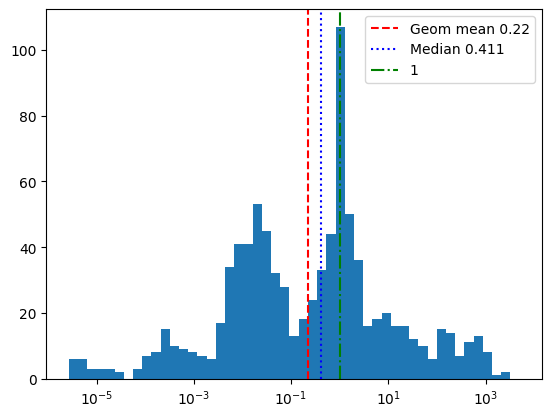

In [53]:
compare_times(data, "prover", "vampire")